# Instacart Customer Shopping Behavior Analysis

## Project Overview

This project analyzes a modified version of Instacart's public grocery-order dataset to explore customer shopping behavior. The workflow includes data inspection, cleaning, exploratory data analysis (EDA), data visualization, and interpretation of purchasing patterns.

### Objectives

- Inspect and clean transactional grocery data
- Investigate duplicate and missing values
- Analyze order activity by time and day
- Study reorder intervals and customer order frequency
- Identify popular and frequently reordered products
- Examine basket size and product reorder behavior


## Dataset

The analysis uses five related tables:

- **instacart_orders.csv** — order-level information
- **order_products.csv** — products included in each order
- **products.csv** — product information
- **aisles.csv** — aisle categories
- **departments.csv** — department categories

The dataset used in this project is a modified subset of Instacart's public 2017 dataset and includes intentionally introduced missing and duplicated values for data-cleaning practice.


## 1. Setup and Data Loading


In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

# Import libraries


In [2]:
df_orders = pd.read_csv('data/instacart_orders.csv', sep=';') 
df_products = pd.read_csv ('data/products.csv', sep=';') 
df_aisles = pd.read_csv ('data/aisles.csv', sep=';') 
df_departments = pd.read_csv('data/departments.csv', sep=';') 
df_order_products = pd.read_csv('data/order_products.csv', sep=';') # Load datasets into DataFrames


## 2. Initial Data Inspection

The first step is to review the structure, data types, descriptive statistics, and sample records from each table.


In [3]:
print(df_orders.head())
print(df_orders.info())
print(df_orders.describe())

# Inspect the DataFrame


   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2          4                 12   

   days_since_prior_order  
0                    30.0  
1                     9.0  
2                     2.0  
3                    10.0  
4                    17.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-nul

In [4]:
print(df_products.head())
print(df_products.info())
print(df_products.describe())# Inspect the DataFrame


   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
N

In [5]:
print(df_aisles.head())
print(df_aisles.info())
print(df_aisles.describe())# Inspect the DataFrame


   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None
         aisle_id
count  134.000000
mean    67.500000
std     38.826537
min      1.000000
25%     34.250000
50%     67.500000
75%    100.750000
max    134.000000


In [6]:
print(df_departments.head())
print(df_departments.info())
print(df_departments.describe())# Inspect the DataFrame


   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None
       department_id
count      21.000000
mean       11.000000
std         6.204837
min         1.000000
25%         6.000000
50%        11.000000
75%        16.000000
max        21.000000


In [7]:
print(df_order_products.head())
print(df_order_products.info())
print(df_order_products.describe())# Inspect the DataFrame


   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype  
---  ------             -----  
 0   order_id           int64  
 1   product_id         int64  
 2   add_to_cart_order  float64
 3   reordered          int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None
           order_id    product_id  add_to_cart_order     reordered
count  4.545007e+06  4.545007e+06       4.544171e+06  4.545007e+06
mean   1.711166e+06  2.558084e+04       8.351669e+00  5.905025e-01
std    9.850955e+05  1.409552e+04       7.080368e+00  4.917411e-01
min    4.000000e+00  1.000000e+00       1.00000

The datasets contain order-level, product-level, aisle, department, and order-product relationship data. Initial inspection also reveals missing values in selected columns that require further investigation.


## 3. Data Cleaning


### 3.1 Duplicate Orders


In [8]:
orders_dup = df_orders.duplicated()
orders_dup_sum = df_orders.duplicated().sum()

print(orders_dup)
print(orders_dup_sum) # Check for duplicated orders


0         False
1         False
2         False
3         False
4         False
          ...  
478962    False
478963    False
478964    False
478965    False
478966    False
Length: 478967, dtype: bool
15


In [9]:
# Com base nas suas conclusões,

order_hour = df_orders[(df_orders['order_hour_of_day'] == 2) & (df_orders['order_dow'] == 3)]

print(order_hour) # verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

In [10]:
df_orders = df_orders.drop_duplicates()
print(df_orders) # Remove duplicated orders


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
0        1515936   183418            11          6                 13   
1        1690866   163593             5          5                 12   
2        1454967    39980             4          5                 19   
3        1768857    82516            56          0                 20   
4        3007858   196724             2          4                 12   
...          ...      ...           ...        ...                ...   
478962   3210681     5617             5          1                 14   
478963   3270802   112087             2          3                 13   
478964    885349    82944            16          2                 11   
478965    216274     4391             3          3                  8   
478966   2071924     1730            18          1                 14   

        days_since_prior_order  
0                         30.0  
1                          9.0  
2                       

In [11]:
orders_dup = df_orders.duplicated().sum() 
print(orders_dup) # Confirm duplicates were removed


0


Duplicate order records were identified and removed. The duplicate pattern was investigated by checking orders placed on Wednesday at 2 AM before continuing with the analysis.


### 3.2 Product, Department, Aisle, and Order-Product Duplicates


In [13]:
products_dup = df_products.duplicated().sum() 
print(products_dup) # Verifique se há linhas completamente duplicadas


0


In [14]:
id_products_dup = df_products['product_id'].duplicated().sum()
print(id_products_dup) # Verifique apenas IDs dos produtos duplicados


0


In [15]:
name_products_dup = df_products['product_name'].str.lower().duplicated().sum()
print(name_products_dup) # Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)


1361


In [16]:
name_dup = df_products[~df_products['product_name'].isna()]['product_name'].str.lower().duplicated().sum()
print(name_dup) # Verifique os nomes de produtos duplicados que não estão faltando


104


In [17]:
departments_dup = df_departments.duplicated().sum()
print(departments_dup) # Verifique se há linhas completamente duplicadas


0


In [18]:
id_departments_dup = df_departments['department_id'].duplicated().sum() 
print(id_departments_dup) # Verifique apenas se há IDs dos produtos duplicados


0


In [19]:
aisles_dup = df_aisles.duplicated().sum()
print(aisles_dup) # Verifique se há linhas completamente duplicadas


0


In [20]:
id_aisles_dup = df_aisles['aisle_id'].duplicated().sum()
print(id_aisles_dup) # Verifique apenas se há IDs dos produtos duplicados


0


In [21]:
order_products_dup = df_order_products.duplicated().sum() 
print(order_products_dup)
 # Verifique se há linhas completamente duplicadas


0


In [55]:
order_products_dup = df_order_products.duplicated(subset= ['order_id', 'product_id']).sum()
print(order_products_dup)# Verifique mais uma vez se há outros casos complicados de duplicados


0


No complete duplicate rows were found in the product, department, or aisle tables. Product names were also checked after normalization to identify repeated names independently of capitalization. The order-product table was checked using the combination of `order_id` and `product_id`.


### 3.3 Missing Values


In [23]:
product_name_dup = df_products['product_name'].isna().sum()
print(product_name_dup)
# Encontre valores ausentes na coluna 'product_name'


1258


In [24]:
aisle_name_dup = df_products[df_products['product_name'].isna()]['aisle_id'].unique()
print(aisle_name_dup)
 # Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?


[100]


In [25]:
department_name_dup = df_products[df_products['product_name'].isna()]['department_id'].unique()
print(department_name_dup)
# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?


[21]


In [26]:
aisle = df_aisles.loc[df_aisles['aisle_id'] == 100]
department = df_departments.loc[df_departments['department_id'] == 21]

print(aisle)
print(department)

# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.


    aisle_id    aisle
99       100  missing
    department_id department
20             21    missing


Missing product names were concentrated in records associated with aisle ID 100 and department ID 21, which are categories used for missing or unknown product information in this dataset.


In [28]:
orders_nan = df_orders.isna().sum()
print(orders_nan) # Encontre os valores ausentes


order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64


In [29]:
first_orders_nan = df_orders['days_since_prior_order'].isna().sum()
print(first_orders_nan)# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?


28817


Missing values in `days_since_prior_order` are expected for customers' first recorded orders because no previous order exists for those observations.


In [30]:
order_products_aus = df_order_products.isna().sum() 
print(order_products_aus)
# Identify missing values


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [31]:
order_min = df_order_products['add_to_cart_order'].min()
order_max = df_order_products['add_to_cart_order'].max() 

print(order_min)
print(order_max) # Check the minimum and maximum values


1.0
64.0


In [32]:
orders_nan = df_order_products.loc[df_order_products['add_to_cart_order'].isna(), 'order_id'].unique()

print(orders_nan) # Find orders with missing cart positions


[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [33]:
counts_by_order = df_order_products.groupby('order_id')['product_id'].count()
any_over_64 = (counts_by_order.loc[orders_nan] > 64).any()
print(any_over_64)# Check whether affected orders contain more than 64 products
print()
counts_by_order = df_order_products.groupby('order_id')['product_id'].count()
print(counts_by_order)# Count products by order
print()
min_items_order = counts_by_order.loc[orders_nan].min() 
print(min_items_order)# Check the minimum item count among affected orders


True

order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64

65


In [34]:
df_order_products['add_to_cart_order'] = df_order_products['add_to_cart_order'].fillna(999).astype(int) 

print(df_order_products.info())# Preserve affected rows using 999 as a sentinel value and convert to integer


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 138.7 MB
None


Missing `add_to_cart_order` values were associated with unusually large orders. A sentinel value of `999` was used to preserve these records while making the missing cart position explicit.


## 4. Exploratory Data Analysis


### 4.1 Orders by Hour of Day


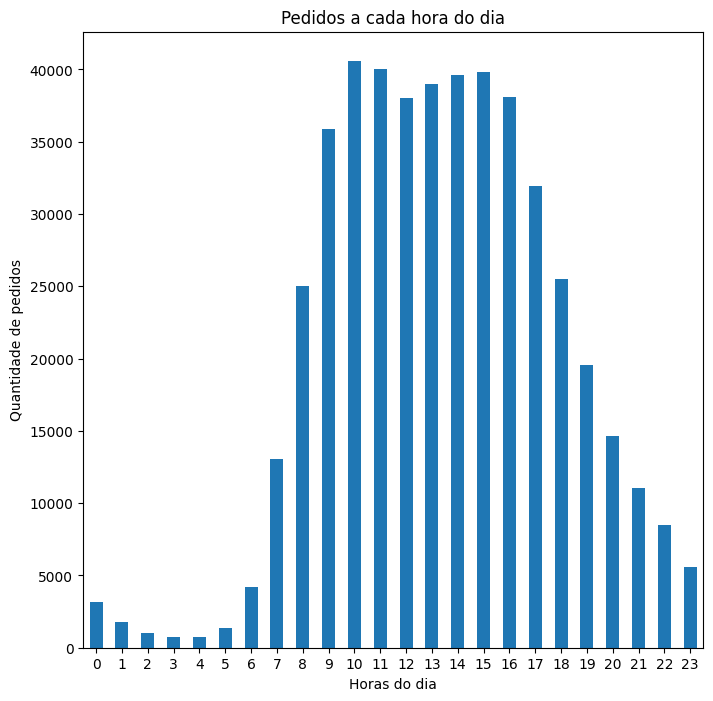

In [37]:
order_hour = df_orders['order_hour_of_day'].value_counts().sort_index()
order_hour.plot(kind= 'bar',
                title= 'Orders by Hour of Day',
                xlabel= 'Hour of Day',
                ylabel= 'Number of Orders',
                figsize= [8,8],
                rot=360
                )
plt.show()


Order activity rises sharply in the morning. The highest and most stable order volume occurs approximately between **9 AM and 4 PM**, followed by a decline later in the day.


### 4.2 Food Orders by Day of Week


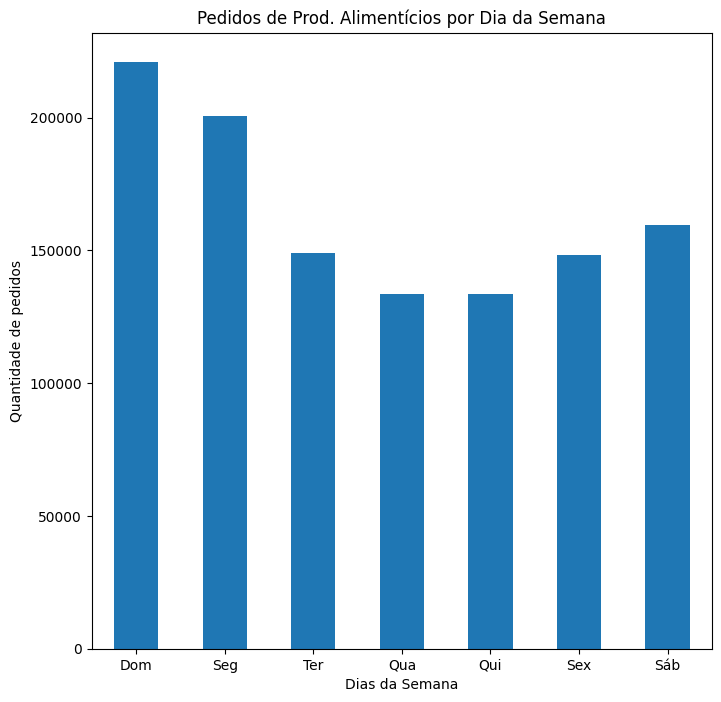

In [39]:
merge = (df_order_products.merge(df_orders, on='order_id').merge(df_products, on='product_id').merge(df_departments, on='department_id'))
food_departments = ['dairy eggs', 'dry goods pasta', 'meat seafood', 'bakery']
food_products = merge[merge['department'].isin(food_departments)]
counts = food_products['order_dow'].value_counts().sort_index()
days = ['Sun', 'Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat']
counts.index = [days[i] for i in counts.index]
counts.plot(kind='bar',
           title= 'Food Orders by Day of Week',
           xlabel= 'Day of Week',
           ylabel= 'Number of Orders',
           figsize= [8,8],
           rot=360
           )
plt.show()


For the selected food-related departments, **Sunday has the highest order volume**. Activity decreases through the middle of the week and begins to increase again toward the weekend.


### 4.3 Time Between Consecutive Orders


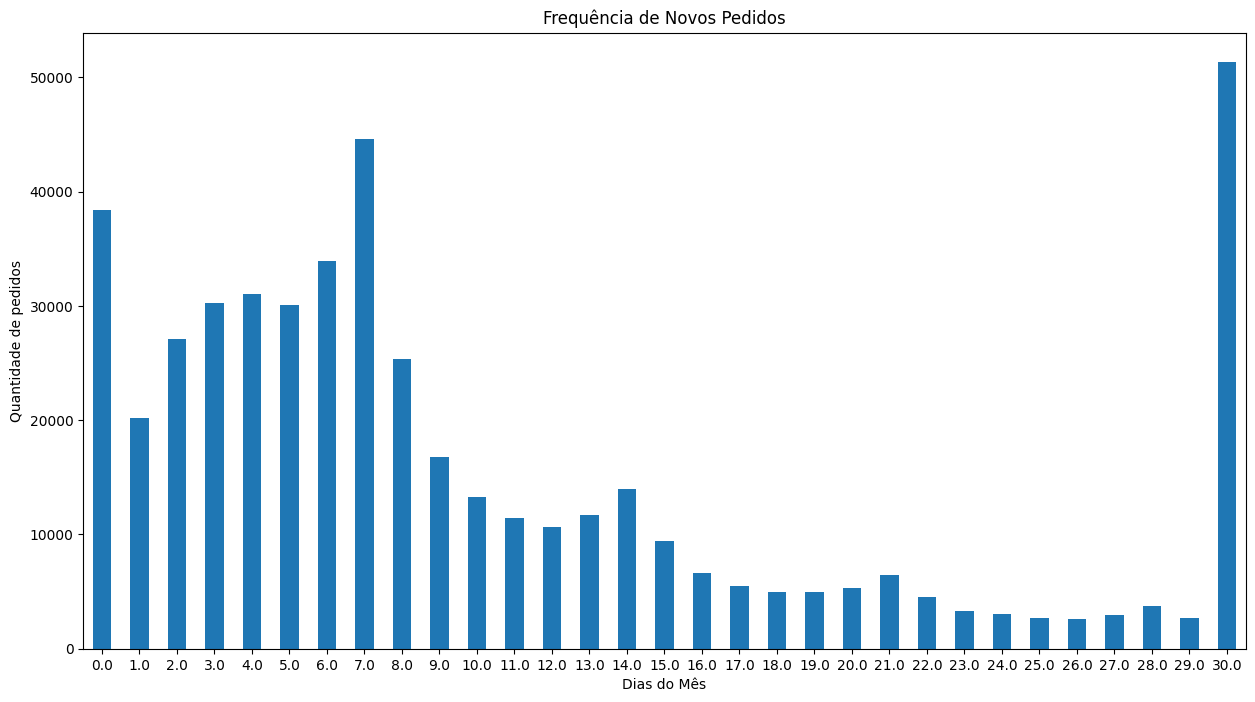

In [40]:
df_orders['days_since_prior_order'] = df_orders['days_since_prior_order'].fillna(0)
order_days = df_orders['days_since_prior_order'].value_counts().sort_index()
order_days.plot(kind='bar',
                title='Time Between Consecutive Orders',
                xlabel='Days Since Prior Order',
                ylabel='Number of Orders',
                figsize= [15,8],
                rot=360
               )

plt.show()


The distribution shows recurring ordering intervals, with weekly and approximately monthly cycles standing out. These patterns suggest that many customers develop regular grocery-order routines.


### 4.4 Wednesday vs. Saturday Order Activity


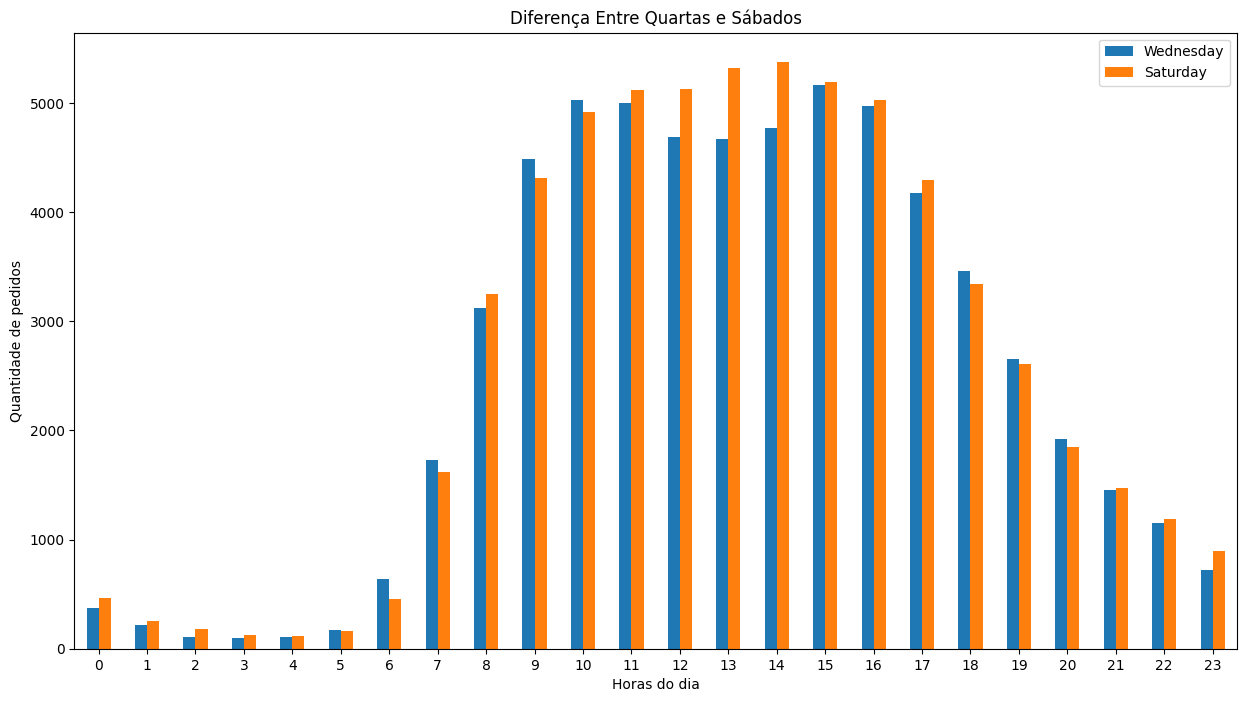

In [41]:
wednesday = df_orders.query("order_dow == 3")['order_hour_of_day'].value_counts()
saturday = df_orders.query("order_dow == 6")['order_hour_of_day'].value_counts()
days = pd.concat([wednesday, saturday], axis=1)
days.columns = ['Wednesday', 'Saturday']
days.plot(kind= 'bar',
          title= 'Wednesday vs. Saturday Order Activity',
          xlabel= 'Hour of Day',
          ylabel= 'Number of Orders',
          figsize= [15, 8],
          rot= 360
         )

plt.show()


Saturday shows higher overall order activity than Wednesday in the analyzed data, while both days follow a similar daily pattern with stronger activity during daytime hours.


### 4.5 Number of Orders per Customer


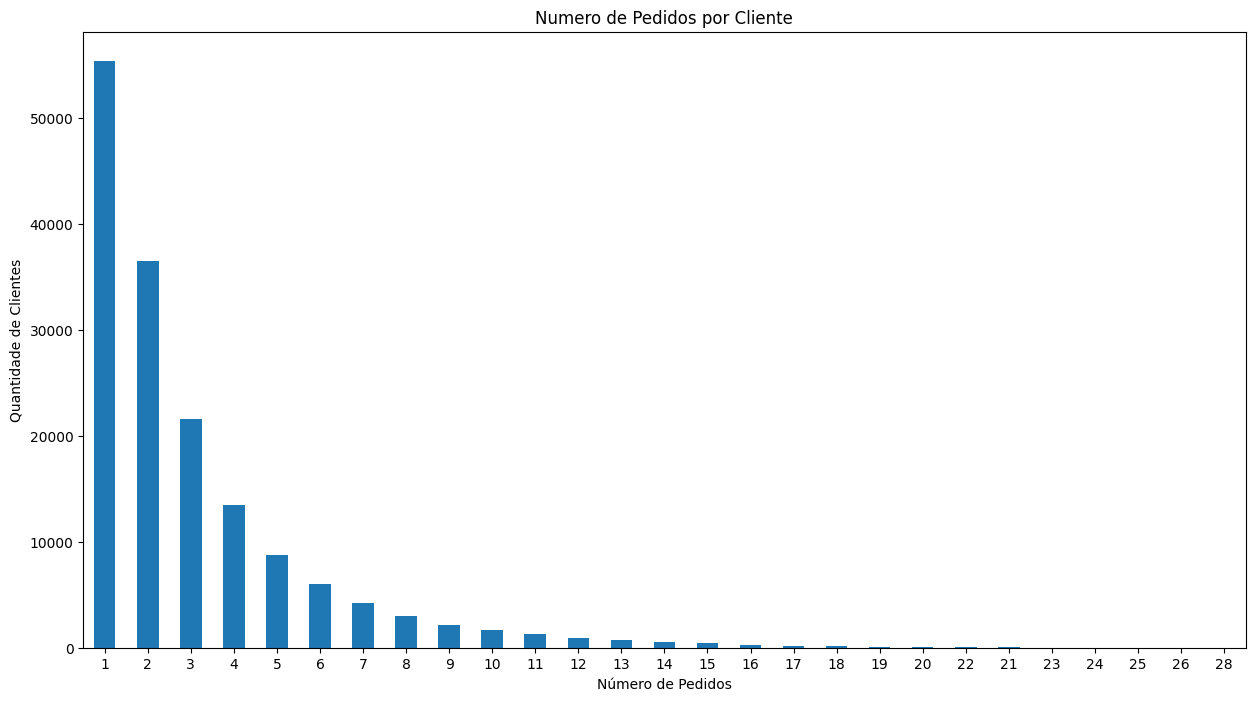

In [42]:
order_per_client = df_orders['user_id'].value_counts().sort_index()
order_per_client = order_per_client.value_counts()
order_per_client.plot(kind='bar',
                      title='Number of Orders per Customer',
                      xlabel= 'Number of Orders',
                      ylabel= 'Number of Customers',
                      figsize= [15,8],
                      rot=360
                     )
plt.show()


Lower order frequencies are the most common. As the number of orders per customer increases, the number of customers at each frequency decreases substantially.


### 4.6 Most Frequently Purchased Products


In [43]:

popular_prod = df_order_products['product_id'].value_counts().reset_index().head(10)
popular_prod.columns = ['product_id', 'buy_count']
popular_prod.merge(df_products[['product_id', 'product_name']], on= 'product_id')


,product_id,buy_count,product_name
0,24852,66050,Banana
1,13176,53297,Bag of Organic Bananas
2,21137,37039,Organic Strawberries
3,21903,33971,Organic Baby Spinach
4,47209,29773,Organic Hass Avocado
5,47766,24689,Organic Avocado
6,47626,21495,Large Lemon
7,16797,20018,Strawberries
8,26209,19690,Limes
9,27845,19600,Organic Whole Milk


The most frequently purchased product is **Banana**, followed by **Bag of Organic Bananas, Organic Strawberries, Organic Baby Spinach, and Organic Hass Avocado**. Fresh produce and organic products are strongly represented among the most popular items.


### 4.7 Basket Size Distribution


In [44]:
order_item = df_order_products.groupby('order_id')['product_id'].count()
print(order_item)


order_id
4          13
9          15
11          5
19          3
20          8
           ..
3421034    17
3421053     9
3421071     5
3421077     4
3421079     1
Name: product_id, Length: 450046, dtype: int64


In [45]:
order_dist = order_item.value_counts().sort_index()
print(order_dist)


1      21847
2      26292
3      29046
4      31054
5      31923
       ...  
98         1
104        1
108        1
115        1
127        1
Name: product_id, Length: 90, dtype: int64


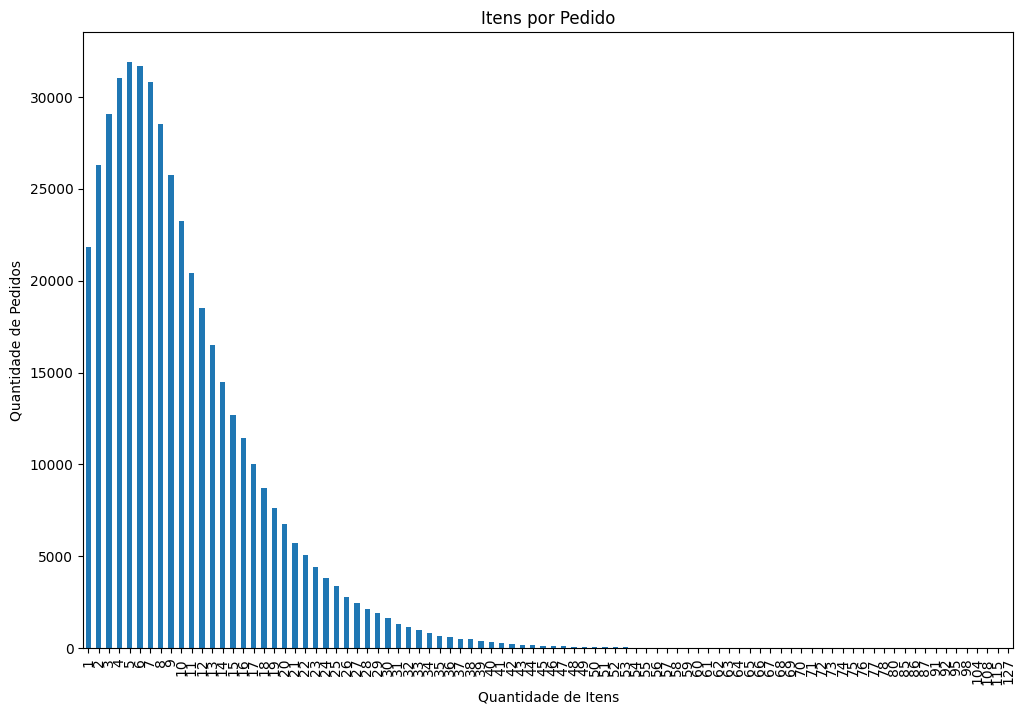

In [46]:
order_dist.plot(kind='bar',
                title= 'Items per Order',
                xlabel= 'Number of Items',
                ylabel= 'Number of Orders',
                figsize= [12,8],
                rot=90
               )
plt.show()


Small and medium-sized baskets are the most common. Order frequency declines substantially as basket size increases, especially once orders move beyond roughly a dozen items.


### 4.8 Most Frequently Reordered Products


In [47]:
freq_itens = df_order_products[df_order_products['reordered'] == 1]
count_freq = freq_itens['product_id'].value_counts().head(20).reset_index()
count_freq.columns = ['product_id', 'reorder_count']
freq_itens_final = count_freq.merge(df_products[['product_id', 'product_name']], on='product_id', how='left')
print(freq_itens_final)


    product_id  reorder_count              product_name
0        24852          55763                    Banana
1        13176          44450    Bag of Organic Bananas
2        21137          28639      Organic Strawberries
3        21903          26233      Organic Baby Spinach
4        47209          23629      Organic Hass Avocado
5        47766          18743           Organic Avocado
6        27845          16251        Organic Whole Milk
7        47626          15044               Large Lemon
8        27966          14748       Organic Raspberries
9        16797          13945              Strawberries
10       26209          13327                     Limes
11       22935          11145      Organic Yellow Onion
12       24964          10411            Organic Garlic
13       45007          10076          Organic Zucchini
14       49683           9538            Cucumber Kirby
15       28204           8989        Organic Fuji Apple
16        8277           8836  Apple Honeycrisp 

Reorder activity is dominated by many of the same products that lead overall purchase volume. Bananas, berries, avocados, vegetables, and other organic items appear prominently among frequently reordered products.


### 4.9 Reorder Proportion by Product


In [56]:
merge_1 = df_order_products.merge(df_products)
order_prod = merge_1.groupby(['product_id', 'product_name'])['reordered'].mean()
print(order_prod)


product_id  product_name                                                     
1           Chocolate Sandwich Cookies                                           0.564286
2           All-Seasons Salt                                                     0.000000
3           Robust Golden Unsweetened Oolong Tea                                 0.738095
4           Smart Ones Classic Favorites Mini Rigatoni With Vodka Cream Sauce    0.510204
7           Pure Coconut Water With Orange                                       0.500000
                                                                                   ...   
49690       HIGH PERFORMANCE ENERGY DRINK                                        0.800000
49691       ORIGINAL PANCAKE & WAFFLE MIX                                        0.430556
49692       ORGANIC INSTANT OATMEAL LIGHT MAPLE BROWN SUGAR                      0.416667
49693       SPRING WATER BODY WASH                                               0.440000
49694       BURRITO- S

The mean of the binary `reordered` field provides the reorder proportion for each product. This allows products to be compared by the share of purchases that came from repeat customers rather than only by total purchase volume.


## 5. Conclusion

This project demonstrates an end-to-end exploratory data analysis workflow using transactional grocery data. After inspecting and cleaning the datasets, the analysis identified clear patterns in shopping time, order frequency, basket size, popular products, and reorder behavior.

The results show that customer activity is concentrated during daytime hours, recurring order intervals are common, smaller baskets dominate the order distribution, and fresh or organic products are highly represented among both popular and frequently reordered items.

These insights could support decisions related to inventory planning, promotional timing, customer retention, and product assortment.
